## Import the required modules

In [1]:
import matplotlib.pyplot as plt
import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any, Dict, Callable
from QMAP_tools.qmap_inspector import QMAPInspector

In [2]:
# Not required but improved the default layout of plots
import scienceplots
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

In [3]:
qm = QMAPInspector()
# Load the helper class which by default has the standard relative paths of the database files so should work out of the box
# in most cases, however if the data is stored else where just use the init kwargs to set the correct path

In [4]:
qm.full_db.filter(pl.col("i") == 1).collect()
# The full database contains all the data needed to make the agg_db and some. It is very important that you do not try load
# the full database into memory so when previewing a standard way is to just filter by pl.col("i") == 1 which restricts the
# database to 1 / 8192 of its full size and therefore can be fully loaded into memory. We are still able to do operations
# on this dataset as you will see later leveraging the LazyFrame.

i,j,face,area,g_00800mm_spc_obj_0000n00000_v042 facet_id,g_01600mm_spc_obj_0000n00000_v042 facet_id,g_03170mm_spc_obj_0000n00000_v020 facet_id,g_06310mm_spc_obj_0000n00000_v020 facet_id,TIR detailed_survey Slope1000,TIR detailed_survey BD350,TIR detailed_survey BD440,TIR detailed_survey Ratio1000,TIR detailed_survey sigma Slope1000,TIR detailed_survey sigma BD350,TIR detailed_survey sigma BD440,TIR detailed_survey sigma Ratio1000,TIR detailed_survey facet mesh,TIR recona Slope1000,TIR recona BD350,TIR recona BD440,TIR recona Ratio1000,TIR recona sigma Slope1000,TIR recona sigma BD350,TIR recona sigma BD440,TIR recona sigma Ratio1000,TIR recona facet mesh,TIR reconb Slope1000,TIR reconb BD350,TIR reconb BD440,TIR reconb Ratio1000,TIR reconb sigma Slope1000,TIR reconb sigma BD350,TIR reconb sigma BD440,TIR reconb sigma Ratio1000,TIR reconb facet mesh,TIR reconc Slope1000,TIR reconc BD350,…,32bit_reflectance,positions_x,positions_y,positions_z,detection_lod_level,detection_lod_code,boulder_id,r32_min,r32_max,r32_range,r32_mean,r32_median,r32_std,r32_variance,r32_q25,r32_q75,r32_q90,r32_q95,r32_sum,r32_product,r32_skew,r32_kurtosis,Area,center_x,min_x,max_x,center_y,min_y,max_y,center_z,min_z,max_z,number_of_samples,g_00800mm_spc_obj_0000n00000_v042 facet_id alpha,g_01600mm_spc_obj_0000n00000_v042 facet_id alpha,g_03170mm_spc_obj_0000n00000_v020 facet_id alpha,g_06310mm_spc_obj_0000n00000_v020 facet_id alpha
u32,u32,str,f32,u64,u64,u64,u64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,…,f32,f32,f32,f32,u8,str,u32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,u32,u64,u64,u64,u64
1,0,"""negx""",0.000676,null,408042,null,25467,1.001857,1.002986,1.010986,null,0.000591,0.001074,0.00058,null,"""g_06310mm_spc_obj_0000n00000_v…",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,0.011107,0.138693,0.13874,-0.138707,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1085,null,17219
1,1,"""negx""",0.000681,null,408042,null,25467,1.001857,1.002986,1.010986,null,0.000591,0.001074,0.00058,null,"""g_06310mm_spc_obj_0000n00000_v…",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,0.010167,0.138667,0.138749,-0.138711,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1085,null,17219
1,2,"""negx""",0.000654,null,408042,null,25467,1.001857,1.002986,1.010986,null,0.000591,0.001074,0.00058,null,"""g_06310mm_spc_obj_0000n00000_v…",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,0.011566,0.138643,0.138756,-0.138716,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1085,null,17219
1,3,"""negx""",0.000647,null,408042,null,25467,1.001857,1.002986,1.010986,null,0.000591,0.001074,0.00058,null,"""g_06310mm_spc_obj_0000n00000_v…",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,0.012794,0.138617,0.138762,-0.138724,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1085,null,17219
1,4,"""negx""",0.000632,null,408042,null,25467,1.001857,1.002986,1.010986,null,0.000591,0.001074,0.00058,null,"""g_06310mm_spc_obj_0000n00000_v…",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,0.012029,0.138591,0.138768,-0.138733,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1085,null,17219
…,…,…,…,…,…,…,…,…,…,…

## Cluster the difference in measurement of two types of band depth between mission faces recona and reconb

In [5]:
from polars.dataframe.frame import DataFrame
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Define your items
x_item, y_item = "Delta 350", "Delta 440"

# Add the custom items as columns in the lazy frame
custom_lf = qm.full_db.with_columns(
    (pl.col("TIR recona BD350") - pl.col("TIR reconb BD350")).alias(x_item),
    (pl.col("TIR recona BD440") - pl.col("TIR reconb BD440")).alias(y_item)
)

# Extract the columns from the lazy frame as a dataframe
X: DataFrame = (
    custom_lf
    .filter(
        pl.col("Delta 350").is_not_nan(),
        pl.col("Delta 440").is_not_nan()
    )
    .select(["Delta 350", "Delta 440"])
    .unique()
    .collect(engine="streaming")
)

# Extract features for clustering
features = (
    X
    .select(["Delta 350", "Delta 440"])
    .to_numpy()
)

# Scale the two dimensions
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# K-means classification
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

# Predict the two populations
labels = kmeans.fit_predict(features_scaled)

# Add labels back into Polars dataframe
X = X.with_columns(
    pl.Series("population", labels)
)

# Cluster centres back in original units
centres = scaler.inverse_transform(kmeans.cluster_centers_)

print(centres)

[[ 0.00042194  0.00095459]
 [-0.00845803 -0.02651719]]


## Plot the k-means groups

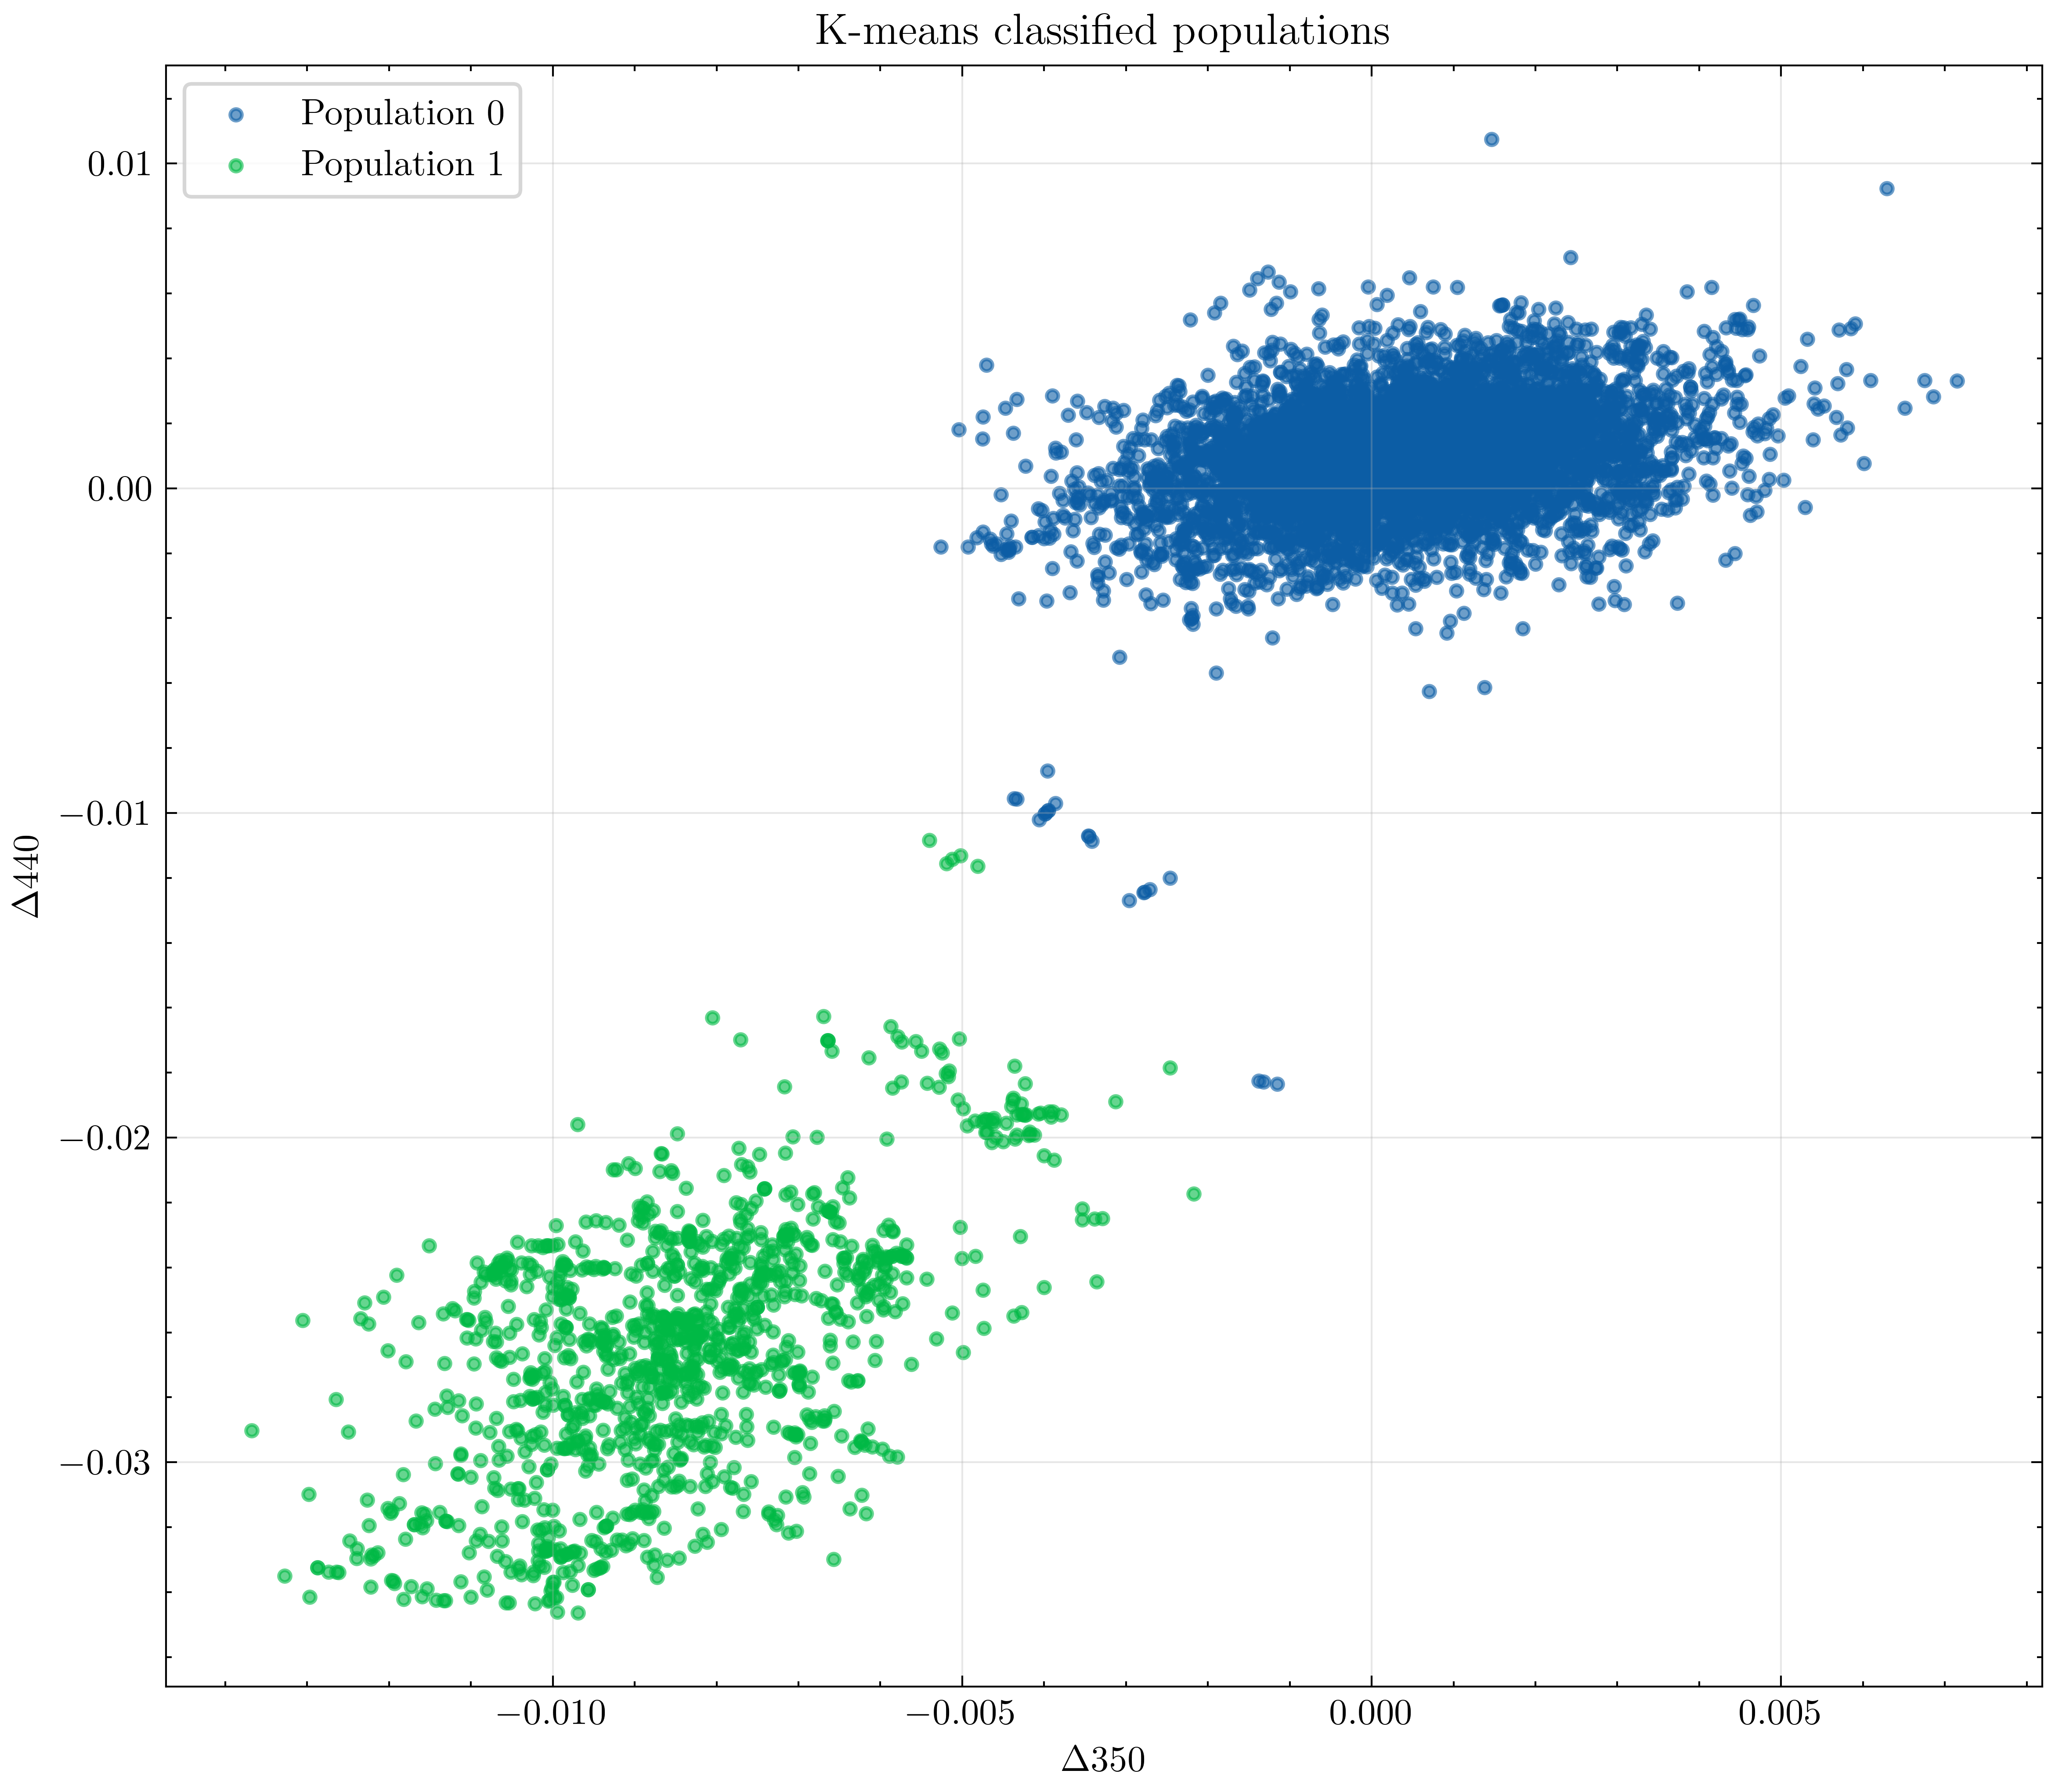

In [7]:
import matplotlib.pyplot as plt

df_plot = X.to_pandas()

plt.figure(figsize=(8, 7))

for pop, group in df_plot.groupby("population"):
    plt.scatter(
        group["Delta 350"],
        group["Delta 440"],
        s=10,
        alpha=0.6,
        label=f"Population {pop}"
    )

plt.xlabel(r"$\Delta 350$")
plt.ylabel(r"$\Delta 440$")
plt.title("K-means classified populations")

plt.legend(frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## Add the group results back into the database on the values of ["Delta 350", "Delta 440"]

In [8]:
# Join
custom_lf_classified = (
    custom_lf
    .join(
        X.select(["Delta 350", "Delta 440", "population"]).lazy(),
        on=["Delta 350", "Delta 440"],
        how="left"
    )
)

In [9]:
ds_columns_of_interest: list[str] = [
    # Raw reflectance
    # "uint8_reflectance",
    "32bit_reflectance",

    # TIR spectral
    "TIR detailed_survey Slope1000",
    "TIR detailed_survey BD350",
    "TIR detailed_survey BD440",
    "TIR detailed_survey Ratio1000",

    "TIR detailed_survey sigma Slope1000",
    "TIR detailed_survey sigma BD350",
    "TIR detailed_survey sigma BD440",

    # VNIR spectral
    "VNIR detailed_survey BandArea3200to3600nm",
    "VNIR detailed_survey OH2700nm",
    "VNIR detailed_survey Pyroxene920nm",
    "VNIR detailed_survey Slope1polyfit",
    "VNIR detailed_survey Slope2polyfit",

    "VNIR detailed_survey sigma BandArea3200to3600nm",
    "VNIR detailed_survey sigma OH2700nm",
    "VNIR detailed_survey sigma Pyroxene920nm",
    "VNIR detailed_survey sigma Slope1polyfit",
    "VNIR detailed_survey sigma Slope2polyfit",
]

## Create a test bed for evaluating how well different metrics can be used to differentiate the two populations

In [ ]:
for column_of_interest in ds_columns_of_interest:
    for pop in [0, 1]:
        # Find the range from the database
        range = qm.get_column_extrema(column_of_interest)

        # Get the counts and bins for a linear binned hist (custom LazyFrame can be used if entered in the kwarg)
        counts, bins = qm.get_column_hist(
            column = column_of_interest,
            bin_range = range,
            bin_number = 50,
            custom_lf=custom_lf_classified.filter(pl.col("population") == pop)
        )

        # Plot the histogram data
        plt.bar(
            bins[:-1],
            counts,
            width=np.diff(bins),
            align="edge",
            label=f"Population {pop}",
            alpha=0.5,
        )

    plt.xlabel(r"mean_test")
    plt.ylabel("Population Density")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.show()
    break

In [37]:
from polars.dataframe.frame import DataFrame

## For each boulder create a test metric "test" to see if it can be used to resolve the two populations
boulder_id_cluster: DataFrame = (
    # Take the dataset which has been merged with the identified populations/groups
    custom_lf_classified

    # Add our test metric
    .with_columns(
        pl.col("TIR detailed_survey Slope1000").alias("test")
    )
    
    # Only consider relevant rows
    .filter(
        pl.col("population").is_not_null(),
        pl.col("test").is_not_nan()
    )

    # Group by each boulder
    .group_by("boulder_id")

    # Define the aggregation
    .agg(
        pl.col("population").first(),
        pl.col("test").mean().alias("mean_test")
    )

    # Stream the result
    .collect(engine="streaming")
)

boulder_id_cluster

boulder_id,population,mean_test
u32,i32,f64
null,1,0.998908
2322995,1,0.996304
1941478,0,0.998755
1933420,0,0.998839
2163381,0,0.998789
…,…,…
2364781,0,1.0008
2364796,0,1.001487
2505791,1,0.995541


## Plot PAN of the groups

In [38]:
custom_lf_classified = (
    custom_lf
    .join(
        X.select(["Delta 350", "Delta 440", "population"]).lazy(),
        on=["Delta 350", "Delta 440"],
        how="left"
    )
)

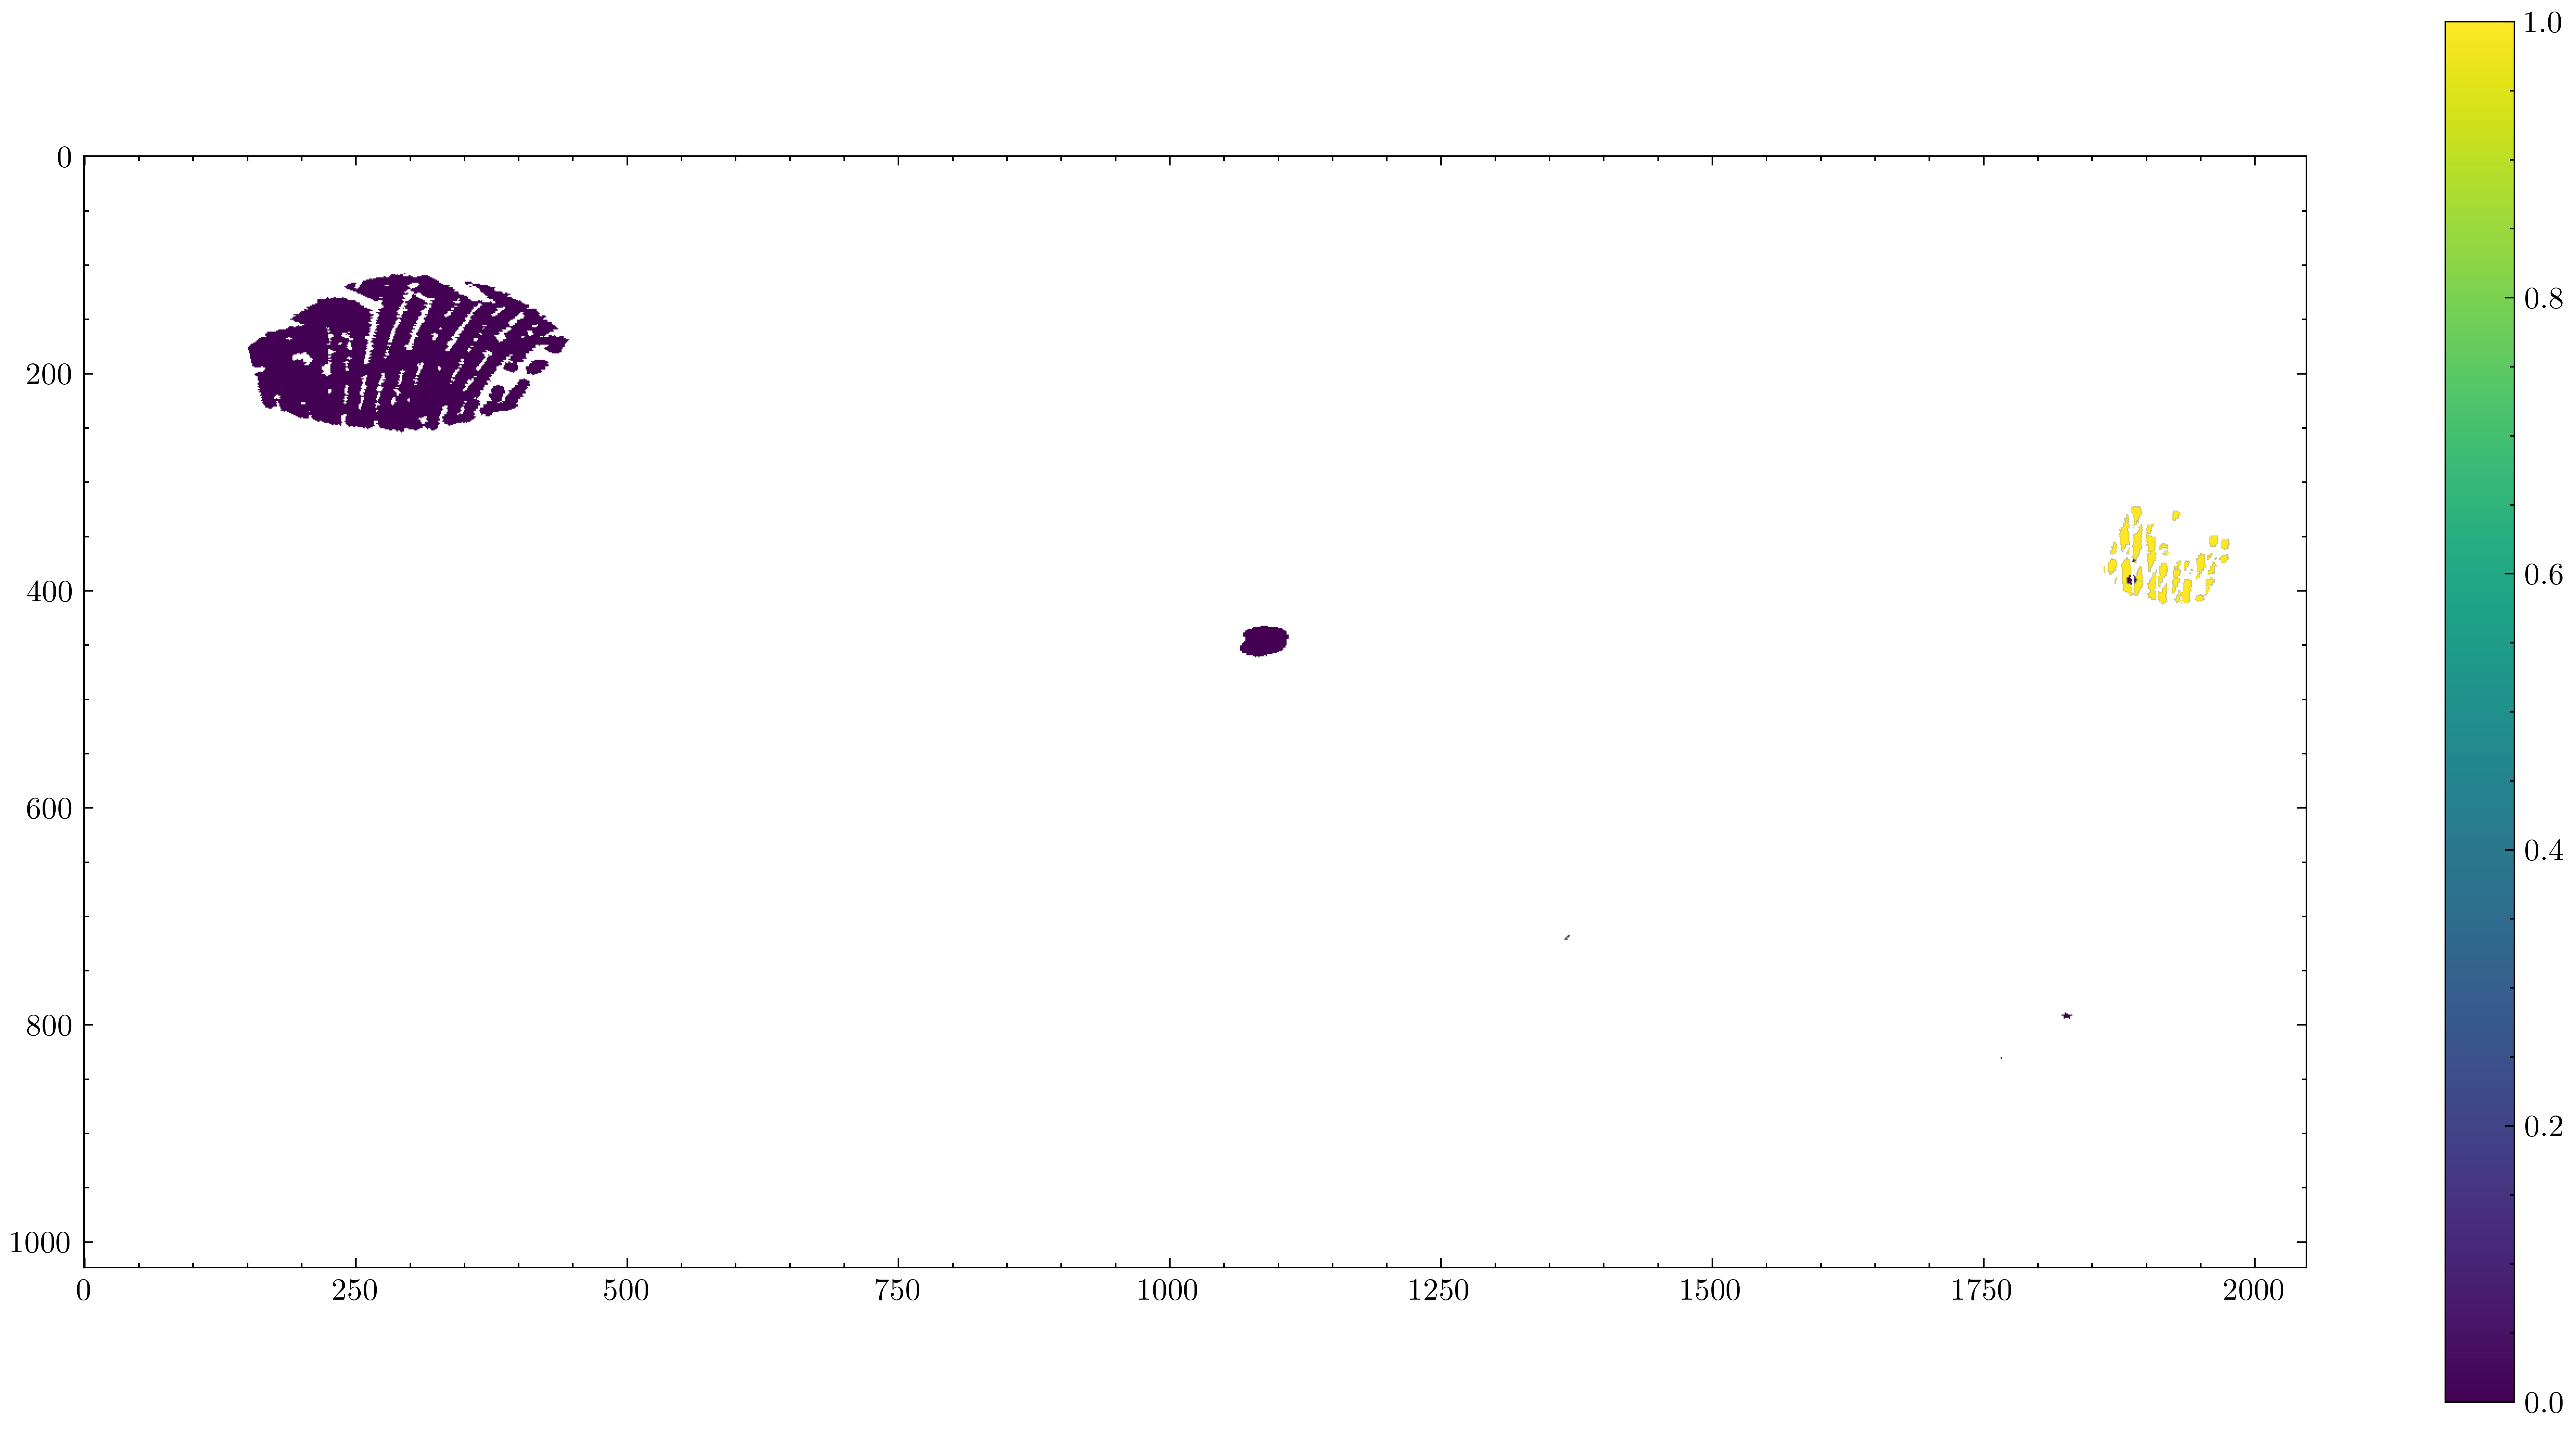

In [39]:
from QMAP_tools.base_map_tools import BaseMapTools

# Render as a panorama with resolution (2048, 1024) by using the "highlighted_large_boulders" column and the db with the
# new column (this will take about 10 seconds)
pan: np.ndarray = BaseMapTools.extract_column_as_equirectangular(
    df = custom_lf_classified,
    column_name="population",
    output_resolution=(2048, 1024)
)

# Plot using plt
plt.figure(figsize=(16, 8))
plt.imshow(pan)
plt.colorbar()
plt.show()

## Plot the results of the test metric

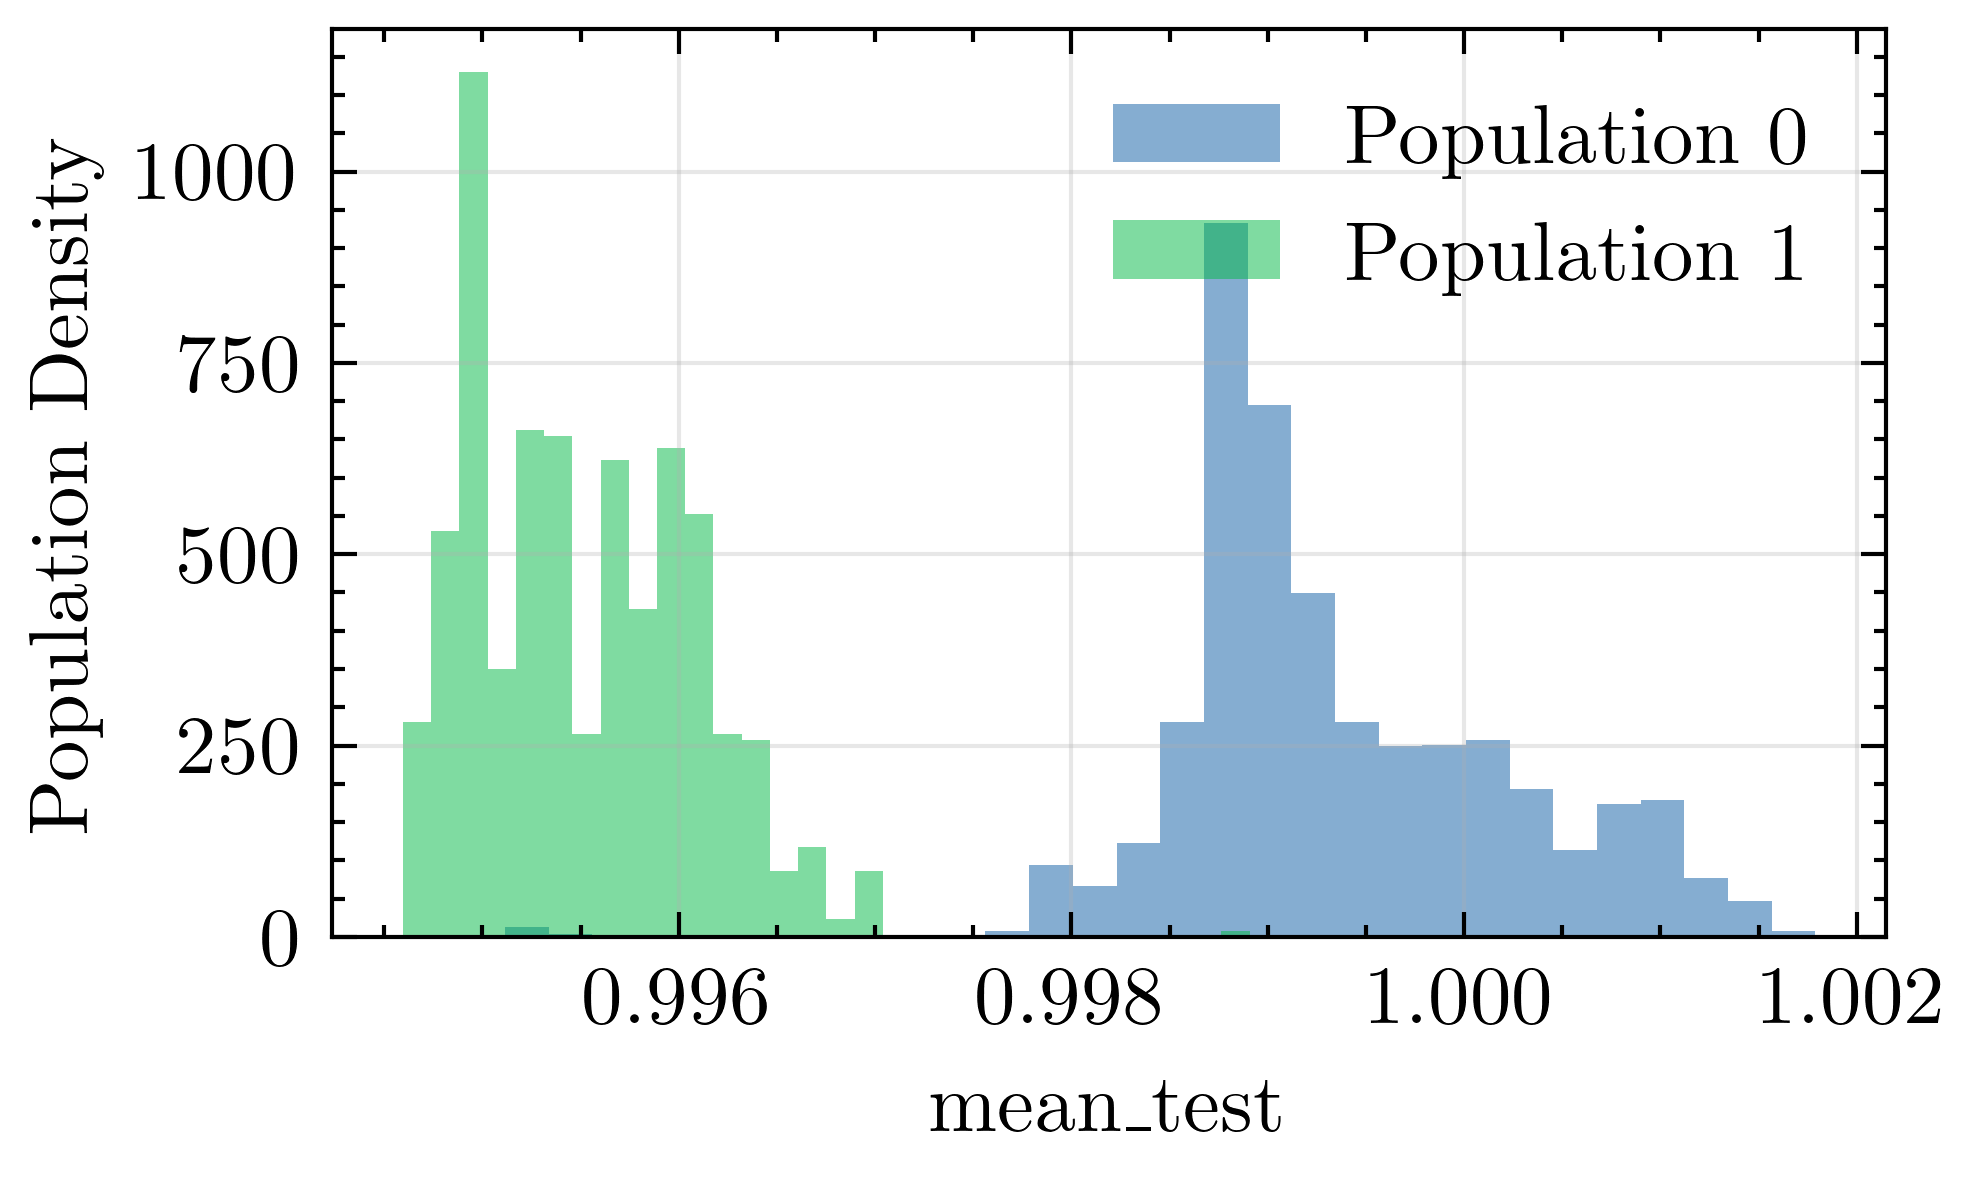

In [40]:
for pop in boulder_id_cluster["population"].unique().sort():
    gamma = (
        boulder_id_cluster
        .filter(pl.col("population") == pop)
        ["mean_test"]
        .to_numpy()
    )

    plt.hist(
        gamma,
        bins=30,
        alpha=0.5,
        density=True,
        label=f"Population {pop}"
    )

plt.xlabel(r"mean_test")
plt.ylabel("Population Density")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()